## Bernardo Frederick Kowe - 0706022310049

## Import Library

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from matplotlib import pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

In [210]:
# load dataset and show the first five sample
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/property_data_clustering_clean.csv"
df = pd.read_csv(url)
df.head()

,Area Category,Nama Daerah,Luas Tanah (m2),Luas Bangunan (m2),Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,Lebar Jalan Depan Rumah (ROW)
0,Standard,Citraland,240,300,4,3,2,3500000000,Belum,Utara,Standard,1-2 Mobil
1,Below Standard,Setro Baru Utara,30,60,2,1,2,287799000,Belum,Utara,Standard,< 1 Mobil
2,Standard,Kenjeran,170,170,5,4,2,2699999999,Belum,Selatan,Cul De Sac/Ujung Gang Buntu,1-2 Mobil
3,Sangat Premium,Kenjeran,187,250,5,5,2,3100000000,Belum,Utara,Standard,1-2 Mobil
4,Premium,Kenjeran,350,600,5,5,2,5000000000,Belum,Barat,Standard,1-2 Mobil


In [211]:
# Check for info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Area Category                  308 non-null    object
 1   Nama Daerah                    308 non-null    object
 2   Luas Tanah (m2)                308 non-null    int64 
 3   Luas Bangunan (m2)             308 non-null    int64 
 4   Jumlah Kamar                   308 non-null    int64 
 5   Jumlah Kamar Mandi             308 non-null    int64 
 6   Tingkat/Lantai                 308 non-null    int64 
 7   Harga Penawaran (dari Owner)   308 non-null    int64 
 8   Terjual/Belum                  308 non-null    object
 9   Arah Hadap Rumah               308 non-null    object
 10  Posisi Rumah                   308 non-null    object
 11  Lebar Jalan Depan Rumah (ROW)  308 non-null    object
dtypes: int64(6), object(6)
memory usage: 29.0+ KB


In [212]:
df.columns

Index(['Area Category', 'Nama Daerah', 'Luas Tanah (m2)', 'Luas Bangunan (m2)',
       'Jumlah Kamar', 'Jumlah Kamar Mandi', 'Tingkat/Lantai ',
       'Harga Penawaran (dari Owner)', 'Terjual/Belum', 'Arah Hadap Rumah',
       'Posisi Rumah', 'Lebar Jalan Depan Rumah (ROW)'],
      dtype='object')

In [213]:
# describe data
df.describe()

,Luas Tanah (m2),Luas Bangunan (m2),Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner)
count,308.000000,308.000000,308.000000,308.000000,308.000000,3.080000e+02
mean,226.951299,266.688312,4.275974,3.337662,1.840909,5.014301e+09
std,201.821447,213.161697,1.643804,1.627215,0.507932,8.311434e+09
min,14.000000,14.000000,1.000000,1.000000,1.000000,1.600000e+08
25%,96.000000,120.000000,3.000000,2.000000,2.000000,1.400000e+09
50%,162.500000,200.000000,4.000000,3.000000,2.000000,2.699500e+09
75%,283.000000,328.750000,5.000000,4.000000,2.000000,4.891667e+09
max,1561.000000,1200.000000,13.000000,13.000000,4.000000,9.900000e+10


In [214]:
# rename nama column yang aneh
df = df.rename(columns={"Luas Tanah (m2)": "Luas Tanah", "Luas Bangunan (m2)": "Luas Bangunan", "Tingkat/Lantai ": "Tingkat/Lantai"})
df.head()

,Area Category,Nama Daerah,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,Lebar Jalan Depan Rumah (ROW)
0,Standard,Citraland,240,300,4,3,2,3500000000,Belum,Utara,Standard,1-2 Mobil
1,Below Standard,Setro Baru Utara,30,60,2,1,2,287799000,Belum,Utara,Standard,< 1 Mobil
2,Standard,Kenjeran,170,170,5,4,2,2699999999,Belum,Selatan,Cul De Sac/Ujung Gang Buntu,1-2 Mobil
3,Sangat Premium,Kenjeran,187,250,5,5,2,3100000000,Belum,Utara,Standard,1-2 Mobil
4,Premium,Kenjeran,350,600,5,5,2,5000000000,Belum,Barat,Standard,1-2 Mobil


In [215]:
# Check for NaN values
df.isna().sum()

,0
Area Category,0
Nama Daerah,0
Luas Tanah,0
Luas Bangunan,0
Jumlah Kamar,0
Jumlah Kamar Mandi,0
Tingkat/Lantai,0
Harga Penawaran (dari Owner),0
Terjual/Belum,0
Arah Hadap Rumah,0


In [216]:
for col in df.columns:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== Area Category ===
Area Category
Standard          140
Premium           106
Below Standard     36
Sangat Premium     26
Name: count, dtype: int64


=== Nama Daerah ===
Nama Daerah
Citraland           34
Gubeng              19
Mulyorejo           18
Pakuwon City        16
Wiyung              11
                    ..
Pakal                1
Asemrowo             1
Tenggilis Mejoyo     1
Dukuh Pakis          1
Teuku Umar           1
Name: count, Length: 126, dtype: int64


=== Luas Tanah ===
Luas Tanah
240    17
120    13
200    12
180    11
96      8
       ..
91      1
216     1
47      1
98      1
193     1
Name: count, Length: 141, dtype: int64


=== Luas Bangunan ===
Luas Bangunan
300    16
200    14
120    12
180    11
150    10
       ..
528     1
246     1
34      1
212     1
156     1
Name: count, Length: 125, dtype: int64


=== Jumlah Kamar ===
Jumlah Kamar
4     80
5     76
3     51
2     45
6     25
7     17
8      9
1      2
9      2
13     1
Name: count, dtype: int64


==

In [217]:
# Nilai Unik
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"\n{col}")
    print(f"Jumlah nilai unik: {df[col].nunique()}")
    print(f"Contoh nilai: {unique_vals[:10]}")


Area Category
Jumlah nilai unik: 4
Contoh nilai: ['Standard' 'Below Standard' 'Sangat Premium' 'Premium']

Nama Daerah
Jumlah nilai unik: 126
Contoh nilai: ['Citraland' 'Setro Baru Utara' 'Kenjeran' 'Gubeng' 'Sawahan' 'Mulyorejo'
 'Tegalsari' 'Tambaksari' 'Kalilom Lor Timur' 'Jelidro Manukan']

Luas Tanah
Jumlah nilai unik: 141
Contoh nilai: [240  30 170 187 350 450  96  85  72  50]

Luas Bangunan
Jumlah nilai unik: 125
Contoh nilai: [300  60 170 250 600 530 100 120  72  90]

Jumlah Kamar
Jumlah nilai unik: 10
Contoh nilai: [ 4  2  5  3  6  8  7  1 13  9]

Jumlah Kamar Mandi
Jumlah nilai unik: 9
Contoh nilai: [ 3  1  4  5  6  2  7  8 13]

Tingkat/Lantai
Jumlah nilai unik: 4
Contoh nilai: [2 1 3 4]

Harga Penawaran (dari Owner)
Jumlah nilai unik: 171
Contoh nilai: [ 3500000000   287799000  2699999999  3100000000  5000000000 10800000000
   390000000   725000000   775000000   850000000]

Terjual/Belum
Jumlah nilai unik: 1
Contoh nilai: ['Belum']

Arah Hadap Rumah
Jumlah nilai unik: 4
Con

In [218]:
# Hapus kolom non-informatif semuanya belum ga informatif samsek :)
df = df.drop(columns=['Terjual/Belum'])

## Harga Rata-rata Berdasarkan Area Category

/tmp/ipython-input-2916469072.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-2916469072.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


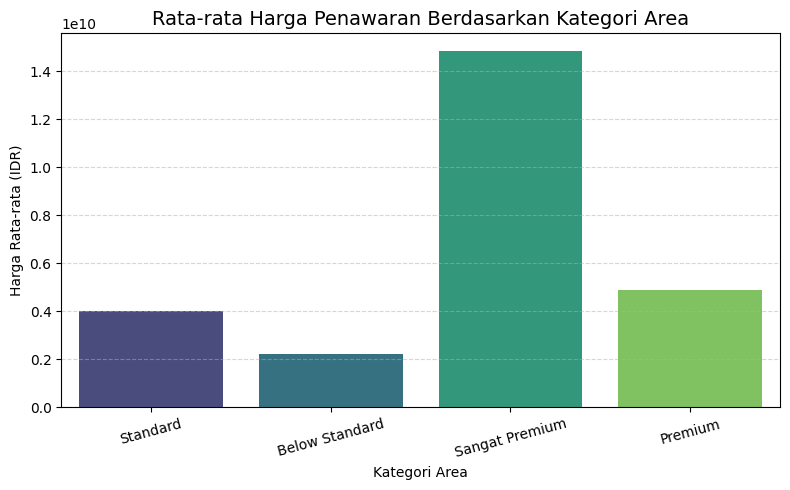

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Area Category',
    y='Harga Penawaran (dari Owner)',
    estimator='mean',
    ci=None,
    palette='viridis'
)
plt.title('Rata-rata Harga Penawaran Berdasarkan Kategori Area', fontsize=14)
plt.ylabel('Harga Rata-rata (IDR)')
plt.xlabel('Kategori Area')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Grafik tersebut menunjukkan rata-rata harga penawaran properti berdasarkan kategori area. Terlihat bahwa kategori “Sangat Premium” memiliki rata-rata harga penawaran tertinggi, jauh melampaui kategori lainnya, dengan nilai sekitar Rp14 miliar. Sementara itu, kategori “Premium” menempati posisi kedua dengan rata-rata sekitar Rp5 miliar, diikuti oleh “Standard” sekitar Rp4 miliar, dan “Below Standard” yang memiliki harga rata-rata terendah sekitar Rp2 miliar.

Perbedaan yang signifikan ini menunjukkan bahwa klasifikasi area berpengaruh kuat terhadap harga properti. Area dengan label “Sangat Premium” kemungkinan berada di lokasi strategis, memiliki fasilitas unggulan, atau lingkungan eksklusif, sehingga harga penawarannya meningkat drastis. Sebaliknya, area “Below Standard” cenderung berada di lokasi kurang strategis atau memiliki kondisi bangunan yang lebih sederhana, yang berdampak pada harga jual yang lebih rendah.

## Korelasi antar Variabel Numerik

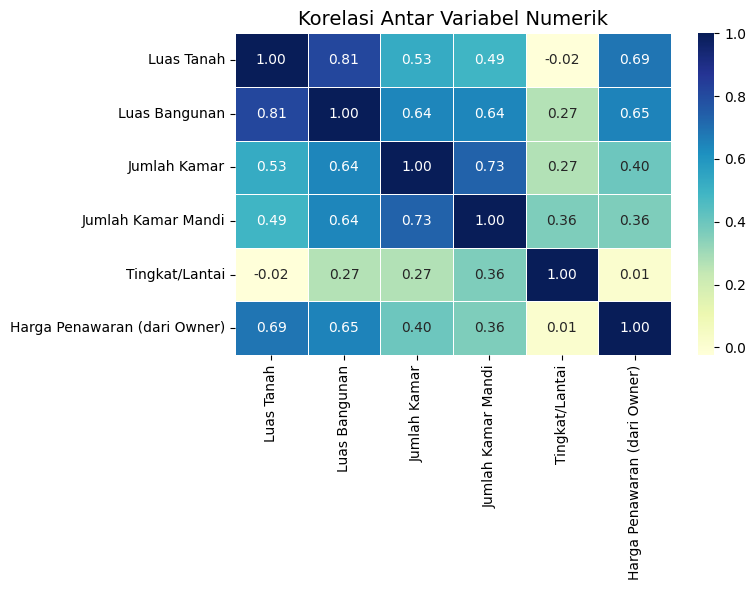

In [220]:
numeric_cols = [
    'Luas Tanah',
    'Luas Bangunan',
    'Jumlah Kamar',
    'Jumlah Kamar Mandi',
    'Tingkat/Lantai',
    'Harga Penawaran (dari Owner)'
]

plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Antar Variabel Numerik', fontsize=14)
plt.tight_layout()
plt.show()


Heatmap korelasi ini memperlihatkan hubungan antar variabel numerik dalam dataset properti, termasuk ukuran, jumlah ruangan, dan harga penawaran. Terlihat bahwa “Luas Tanah” dan “Luas Bangunan” memiliki korelasi sangat kuat (0.81), yang menunjukkan bahwa semakin besar luas tanah, umumnya luas bangunannya juga meningkat.

Selain itu, harga penawaran menunjukkan korelasi cukup tinggi terhadap luas tanah (0.69) dan luas bangunan (0.65), menandakan bahwa kedua faktor tersebut merupakan penentu utama nilai properti. Artinya, semakin besar ukuran lahan dan bangunan, semakin tinggi pula harga penawarannya.

Variabel seperti jumlah kamar (0.40) dan jumlah kamar mandi (0.36) memiliki korelasi sedang terhadap harga, menunjukkan bahwa jumlah ruangan berpengaruh namun tidak sekuat ukuran lahan atau bangunan. Sementara itu, jumlah tingkat/lantai (0.01) hampir tidak memiliki korelasi dengan harga, mengindikasikan bahwa tinggi bangunan bukan faktor utama dalam menentukan nilai jual properti di dataset ini.

Secara keseluruhan, pola korelasi ini menegaskan bahwa faktor fisik utama seperti luas tanah dan bangunan merupakan indikator paling kuat terhadap harga properti, sedangkan variabel lain seperti jumlah kamar atau tingkat hanya berpengaruh secara tambahan.

## Data Preparation

In [228]:
new_df = df.copy()

In [229]:
new_df.head()

,Area Category,Nama Daerah,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Arah Hadap Rumah,Posisi Rumah,Lebar Jalan Depan Rumah (ROW)
0,Standard,Citraland,240,300,4,3,2,3500000000,Utara,Standard,1-2 Mobil
1,Below Standard,Setro Baru Utara,30,60,2,1,2,287799000,Utara,Standard,< 1 Mobil
2,Standard,Kenjeran,170,170,5,4,2,2699999999,Selatan,Cul De Sac/Ujung Gang Buntu,1-2 Mobil
3,Sangat Premium,Kenjeran,187,250,5,5,2,3100000000,Utara,Standard,1-2 Mobil
4,Premium,Kenjeran,350,600,5,5,2,5000000000,Barat,Standard,1-2 Mobil


In [230]:
# Gabungkan kategori minoritas di 'Posisi Rumah'
new_df['Posisi Rumah'] = new_df['Posisi Rumah'].replace({
    'Tusuk Sate': 'Non-Standard',
    'Kantong Belakang/Ngantong': 'Non-Standard',
    'Cul De Sac/Ujung Gang Buntu': 'Non-Standard',
    'Tikungan/Hook': 'Non-Standard'
})

In [231]:
# Nama Daerah
le = LabelEncoder()
new_df['Nama Daerah'] = le.fit_transform(new_df['Nama Daerah'])

# Area Category
new_df['Area Category'] = new_df['Area Category'].map({
    'Below Standard': 0,
    'Standard': 1,
    'Premium': 2,
    'Sangat Premium': 3
})

# Posisi Rumah
new_df['Posisi Rumah'] = new_df['Posisi Rumah'].map({
    'Standard': 0,
    'Non-Standard': 1
})

# Arah Hadap Rumah
new_df['Arah Hadap Rumah'] = new_df['Arah Hadap Rumah'].map({
    'Utara': 0,
    'Selatan': 1,
    'Timur': 2,
    'Barat': 3
})

# Lebar Jalan Depan Rumah (ROW)
new_df['Lebar Jalan Depan Rumah (ROW)'] = new_df['Lebar Jalan Depan Rumah (ROW)'].map({
    '< 1 Mobil': 0,
    '1-2 Mobil': 1,
    '> 2 Mobil': 2
})

In [232]:
new_df.head()

,Area Category,Nama Daerah,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Arah Hadap Rumah,Posisi Rumah,Lebar Jalan Depan Rumah (ROW)
0,1,11,240,300,4,3,2,3500000000,0,0,1
1,0,100,30,60,2,1,2,287799000,0,0,0
2,1,48,170,170,5,4,2,2699999999,1,1,1
3,3,48,187,250,5,5,2,3100000000,0,0,1
4,2,48,350,600,5,5,2,5000000000,3,0,1


In [233]:
for col in new_df.columns:
    print(f"=== {col} ===")
    print(new_df[col].value_counts(dropna=False))
    print("\n")

=== Area Category ===
Area Category
1    140
2    106
0     36
3     26
Name: count, dtype: int64


=== Nama Daerah ===
Nama Daerah
11     34
30     19
73     18
82     16
122    11
       ..
80      1
2       1
116     1
19      1
117     1
Name: count, Length: 126, dtype: int64


=== Luas Tanah ===
Luas Tanah
240    17
120    13
200    12
180    11
96      8
       ..
91      1
216     1
47      1
98      1
193     1
Name: count, Length: 141, dtype: int64


=== Luas Bangunan ===
Luas Bangunan
300    16
200    14
120    12
180    11
150    10
       ..
528     1
246     1
34      1
212     1
156     1
Name: count, Length: 125, dtype: int64


=== Jumlah Kamar ===
Jumlah Kamar
4     80
5     76
3     51
2     45
6     25
7     17
8      9
1      2
9      2
13     1
Name: count, dtype: int64


=== Jumlah Kamar Mandi ===
Jumlah Kamar Mandi
3     73
4     70
2     62
5     45
1     38
6      8
7      7
8      4
13     1
Name: count, dtype: int64


=== Tingkat/Lantai ===
Tingkat/Lantai
2   

## Data Transformation

In [234]:
# Copy dataset supaya aman
df_scaled = new_df.copy()

# Pilih semua kolom numerik / sudah di-encode
features = [
    'Luas Tanah', 'Luas Bangunan', 'Jumlah Kamar', 'Jumlah Kamar Mandi',
    'Tingkat/Lantai', 'Harga Penawaran (dari Owner)',
    'Nama Daerah', 'Area Category', 'Posisi Rumah',
    'Arah Hadap Rumah', 'Lebar Jalan Depan Rumah (ROW)'
]

# Buat StandardScaler
sc = StandardScaler()

# Fit dan transform
scaled_array = sc.fit_transform(df_scaled[features])

# Kembalikan ke DataFrame dengan kolom yang sama
df_scaled = pd.DataFrame(scaled_array, columns=features)
df_scaled.head()

,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Nama Daerah,Area Category,Posisi Rumah,Arah Hadap Rumah,Lebar Jalan Depan Rumah (ROW)
0,0.064760,0.156529,-0.168161,-0.207847,0.313723,-0.182491,-1.370742,-0.494434,-0.334535,-0.791102,-0.598758
1,-0.977457,-0.971209,-1.386831,-1.438941,0.313723,-0.569600,1.047509,-1.742677,-0.334535,-0.791102,-2.406773
2,-0.282646,-0.454330,0.441174,0.407700,0.313723,-0.278901,-0.365402,-0.494434,2.989228,0.291829,-0.598758
3,-0.198276,-0.078417,0.441174,1.023247,0.313723,-0.230696,-0.365402,2.002052,-0.334535,-0.791102,-0.598758
4,0.610683,1.566201,0.441174,1.023247,0.313723,-0.001723,-0.365402,0.753809,-0.334535,2.457690,-0.598758


In [235]:
# get stastical information on the new dataset
df_scaled.describe()

,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Nama Daerah,Area Category,Posisi Rumah,Arah Hadap Rumah,Lebar Jalan Depan Rumah (ROW)
count,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02
mean,2.306957e-17,8.651089e-17,-1.153478e-16,2.883696e-17,1.672544e-16,-2.451142e-17,2.306957e-17,6.920871e-17,6.632501e-17,-8.074349e-17,-4.613914e-17
std,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00
min,-1.056864e+00,-1.187359e+00,-1.996166e+00,-1.438941e+00,-1.658248e+00,-5.850015e-01,-1.669627e+00,-1.742677e+00,-3.345345e-01,-7.911019e-01,-2.406773e+00
25%,-6.499032e-01,-6.892750e-01,-7.774956e-01,-8.233942e-01,3.137225e-01,-4.355666e-01,-8.612793e-01,-4.944339e-01,-3.345345e-01,-7.911019e-01,-5.987582e-01
50%,-3.198678e-01,-3.133623e-01,-1.681606e-01,-2.078471e-01,3.137225e-01,-2.789613e-01,5.575423e-02,-4.944339e-01,-3.345345e-01,-7.911019e-01,-5.987582e-01
75%,2.781662e-01,2.916222e-01,4.411744e-01,4.077000e-01,3.137225e-01,-1.477895e-02,8.844808e-01,7.538091e-01,-3.345345e-01,2.918287e-01,1.209257e+00
max,6.620801e+00,4.385546e+00,5.315854e+00,5.947624e+00,4.257663e+00,1.132640e+01,1.726793e+00,2.002052e+00,2.989228e+00,2.457690e+00,1.209257e+00


## Silhouette Score

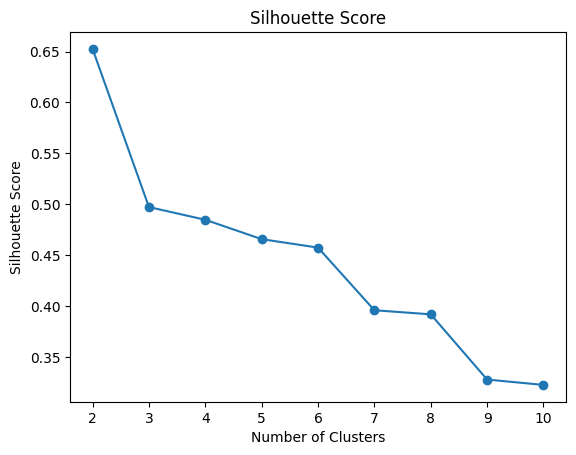

In [236]:
# this is way to show only 1 sillhouette score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    # Create a new AgglomerativeClustering instance for each number of clusters
    agglo_model = AgglomerativeClustering(n_clusters=i, linkage='single')
    cluster_labels = agglo_model.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Score = the higher the better
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

## Comparing Silhouette Score to get best combination of linkage and metric

Skipping Ward linkage with Manhattan metric (not supported).


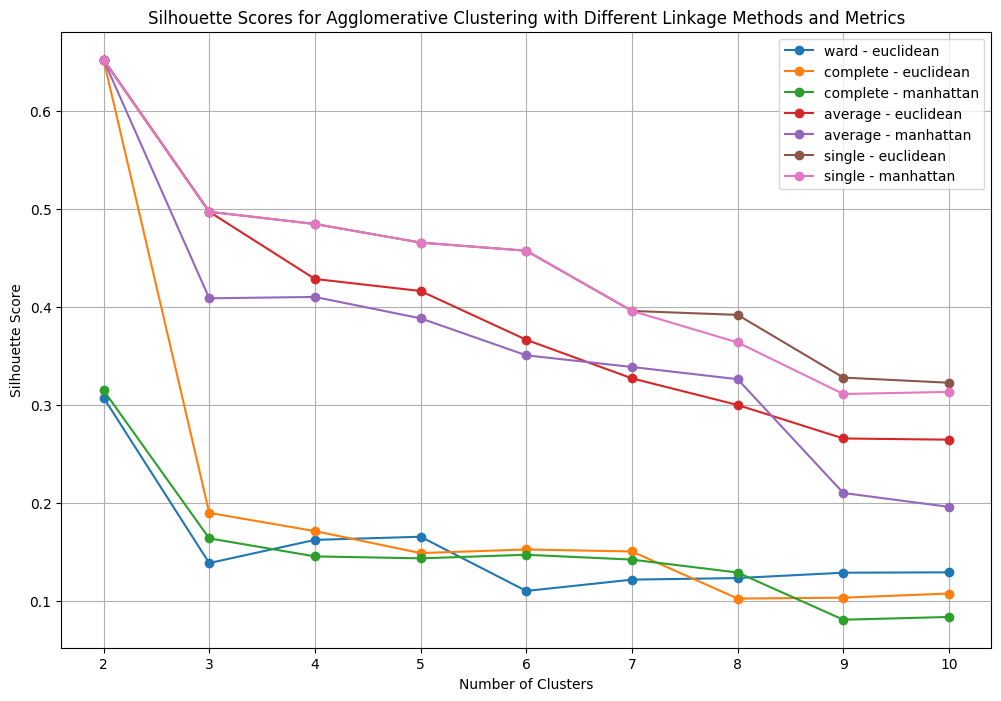

Best Silhouette Score: 0.65256457569882
Optimal Number of Clusters: 2
Optimal Linkage Method: complete
Optimal Metric: euclidean


In [237]:
# Define the range of clusters to test and linkage methods
range_n_clusters = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan']

best_silhouette_score = -1
best_n_clusters = 0
best_linkage = ''
best_metric = ''

results_for_plotting = []

for linkage_method in linkage_methods:
    for metric in metrics:
        # Skip 'ward' linkage with 'manhattan' metric as it's not supported
        if linkage_method == 'ward' and metric == 'manhattan':
            print(f"Skipping Ward linkage with Manhattan metric (not supported).")
            continue

        current_scores = []
        for n_clusters in range_n_clusters:
            agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric=metric)
            y_agglo = agglo.fit_predict(df_scaled)
            silhouette_avg = silhouette_score(df_scaled, y_agglo)
            current_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_n_clusters = n_clusters
                best_linkage = linkage_method
                best_metric = metric
        results_for_plotting.append({
            'linkage': linkage_method,
            'metric': metric,
            'scores': current_scores
        })

# Plot the silhouette scores for each linkage method and metric combination
plt.figure(figsize=(12, 8))
for result in results_for_plotting:
    plt.plot(range_n_clusters, result['scores'], marker='o', label=f"{result['linkage']} - {result['metric']}")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Agglomerative Clustering with Different Linkage Methods and Metrics")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Silhouette Score: {best_silhouette_score}")
print(f"Optimal Number of Clusters: {best_n_clusters}")
print(f"Optimal Linkage Method: {best_linkage}")
print(f"Optimal Metric: {best_metric}")

1. Silhouette Score 0.65
    - Skor silhouette berkisar dari -1 sampai 1.
    - Nilai 0.65 tergolong baik, artinya cluster yang terbentuk cukup jelas, tiap titik berada dekat dengan anggota clusternya sendiri dan jauh dari cluster lain.
    - Ini menunjukkan bahwa pembagian cluster cukup konsisten dan berbeda secara signifikan.

2. Optimal Number of Clusters = 2
    - Dari eksperimen, membagi dataset menjadi 2 cluster memberikan struktur yang paling jelas menurut silhouette score.
    - Artinya, secara umum data rumah bisa dibagi menjadi dua kelompok utama berdasarkan fitur seperti luas, harga, jumlah kamar, arah, dan kategori rumah.

3. Linkage Method: complete
    - Complete linkage menggunakan jarak maksimum antar titik cluster saat penggabungan.
    - Cocok untuk membentuk cluster yang compact dan mencegah cluster yang terlalu longgar atau menyebar.
    - Hal ini sesuai karena rumah yang mirip secara ukuran, harga, dan posisi sebaiknya dikelompokkan secara tight.

4. Distance Metric: euclidean
    - Euclidean adalah jarak “straight line” di ruang multidimensi.
    - Cocok karena semua fitur sudah distandarisasi, sehingga skala yang berbeda tidak mendominasi pengukuran jarak.

## Dendogram Visualization

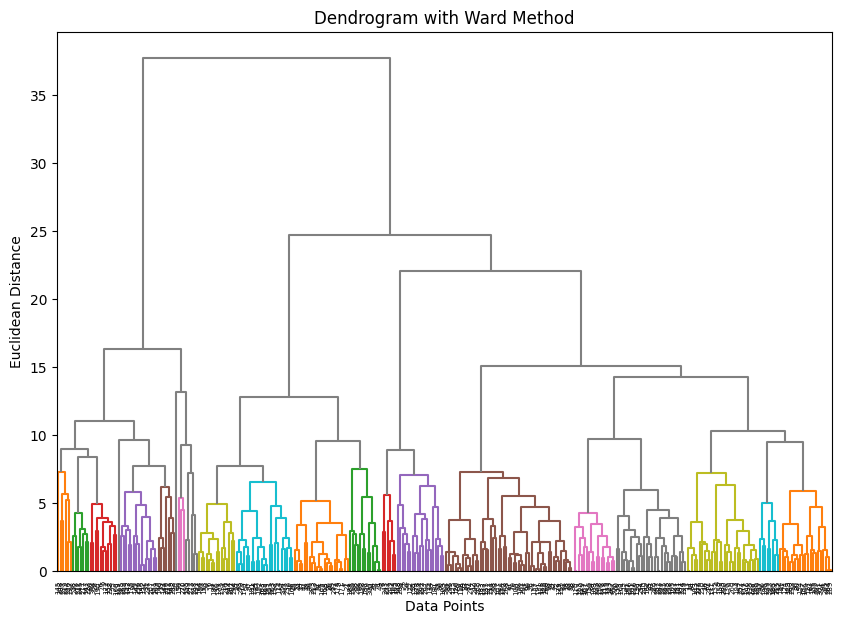

In [238]:
# Ward Method
linked = linkage(df_scaled, method='ward', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked, above_threshold_color="grey", color_threshold=7.5)
plt.title("Dendrogram with Ward Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

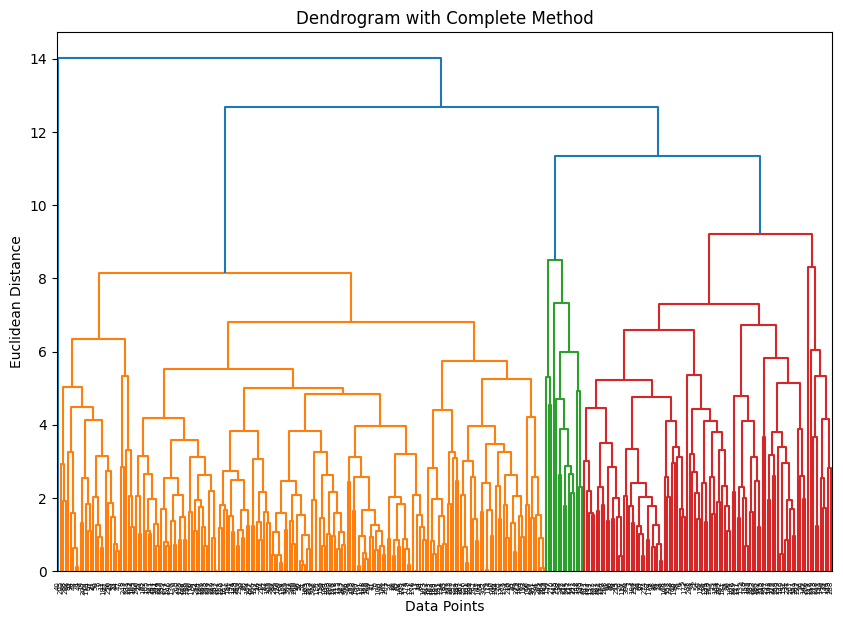

In [239]:
# Max Distance
linked = linkage(df_scaled, method='complete', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Complete Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

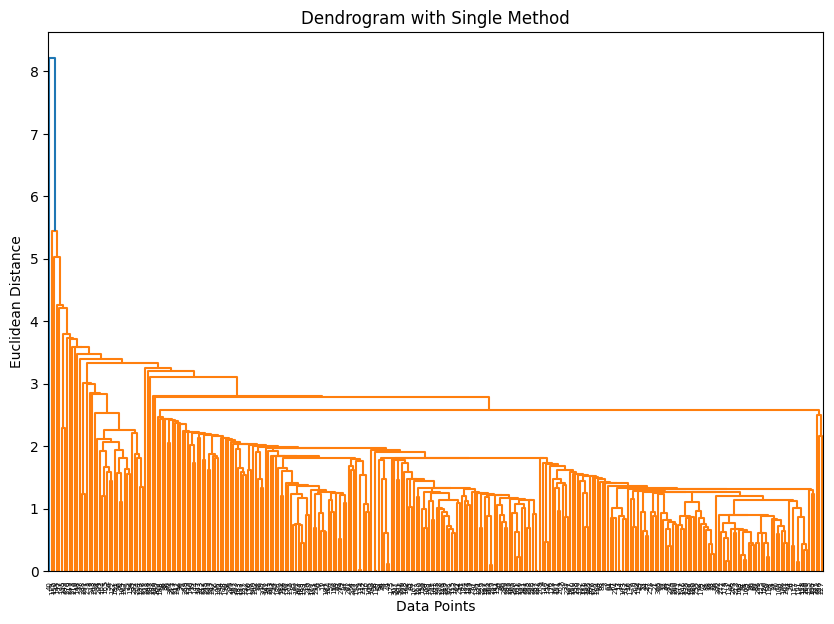

In [240]:
# Min Distance
linked = linkage(df_scaled, method='single')

# Plot dendrogram dengan color_threshold yang sesuai
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Single Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

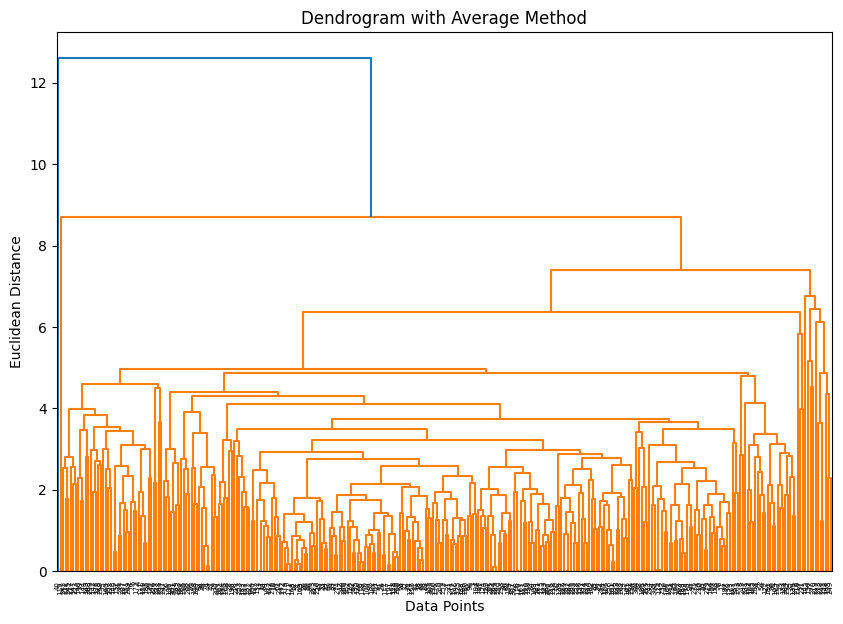

In [241]:
# Average Distance
linked = linkage(df_scaled, method='average', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with Average Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Hierarchical Clustering Model

In [258]:
# metric itu jarak antara titik dalam 1 cluster
# linkage itu jarak antar clusternya
# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage, metric=best_metric)
y_hc = agglo.fit_predict(df_scaled)

In [259]:
# Evaluation
ss = silhouette_score(df_scaled, y_hc)
print(ss)

0.65256457569882


In [260]:
model_ward = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_ward = model_ward.fit_predict(df_scaled)

In [262]:
# Evaluation
ss_ward = silhouette_score(df_scaled, labels_ward)
print(ss_ward)

0.3072879990786839


## Dendogram Visualization for Hierarchical Clustering Model

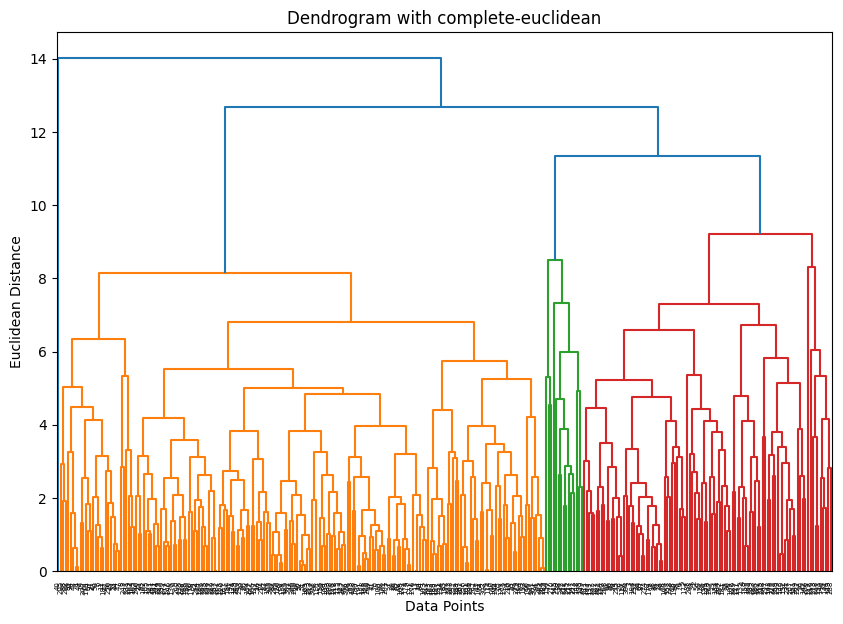

In [263]:
# Average Distance
linked = linkage(df_scaled, method=best_linkage, metric=best_metric)

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with " + best_linkage + "-" + best_metric)
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

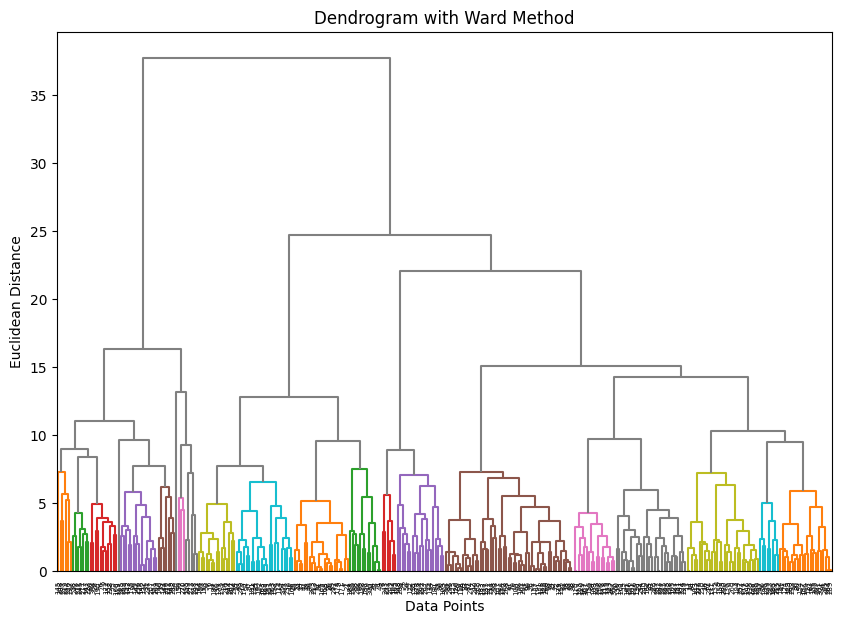

In [264]:
n_clusters = 2  # ambil dari hasil Part C
linked_ward = linkage(df_scaled, method='ward')  # metric = euclidean otomatis

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked_ward, above_threshold_color="grey", color_threshold=7.5)
plt.title("Dendrogram with Ward Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Merge with the original data

In [265]:
# Add the cluster labels to the original data
new_df['Agglo'] = y_hc
new_df['Cluster_Ward'] = labels_ward
# Analyze the clusters with the original values
new_df.head()

,Area Category,Nama Daerah,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Arah Hadap Rumah,Posisi Rumah,Lebar Jalan Depan Rumah (ROW),Agglo,Cluster_Ward
0,1,11,240,300,4,3,2,3500000000,0,0,1,0,0
1,0,100,30,60,2,1,2,287799000,0,0,0,0,0
2,1,48,170,170,5,4,2,2699999999,1,1,1,0,0
3,3,48,187,250,5,5,2,3100000000,0,0,1,0,0
4,2,48,350,600,5,5,2,5000000000,3,0,1,0,0


### BEST PARAMETERS

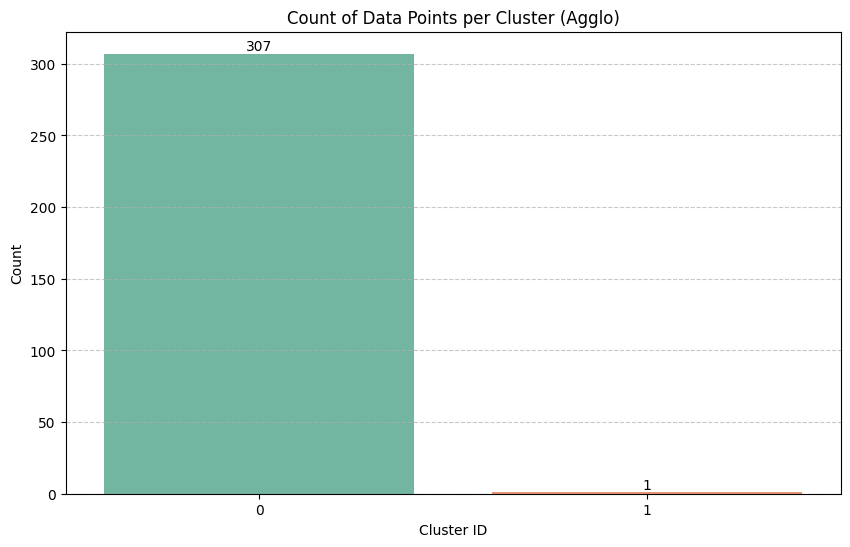

In [268]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'Agglo' column of df
cluster_counts = new_df['Agglo'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='Set2', legend=False)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (Agglo)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### WARD

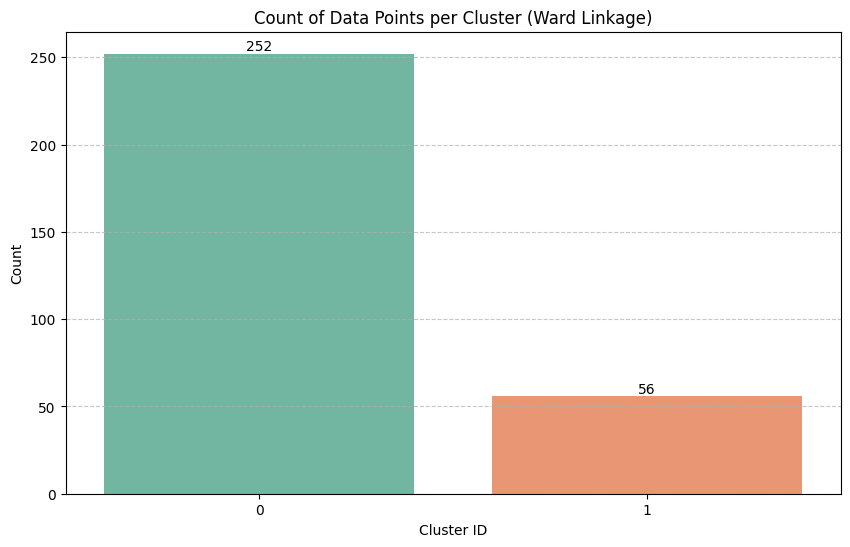

In [269]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'Agglo' column of df
cluster_counts = new_df['Cluster_Ward'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    hue=cluster_counts.index,
    palette='Set2',
    dodge=False,
    legend=False
)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (Ward Linkage)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


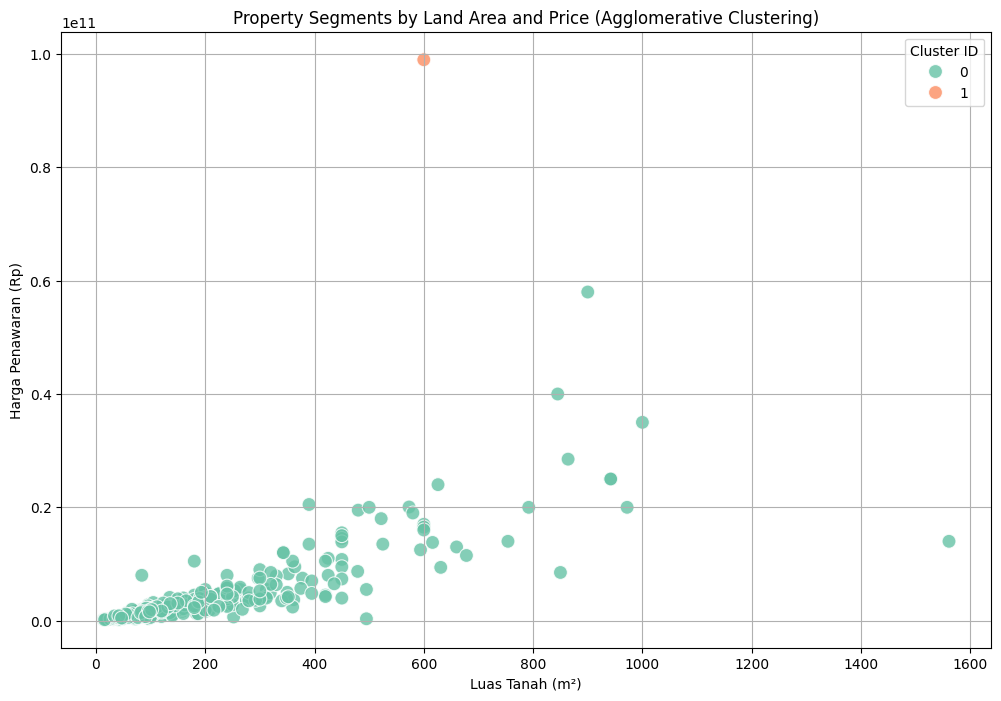

In [287]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.scatterplot(data=new_df,
                x='Luas Tanah',
                y='Harga Penawaran (dari Owner)',
                hue=new_df['Agglo'].astype(str),  # Cluster sebagai warna
                palette='Set2',
                s=100,
                alpha=0.8)

plt.title('Property Segments by Land Area and Price (Agglomerative Clustering)')
plt.xlabel('Luas Tanah (m²)')
plt.ylabel('Harga Penawaran (Rp)')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()


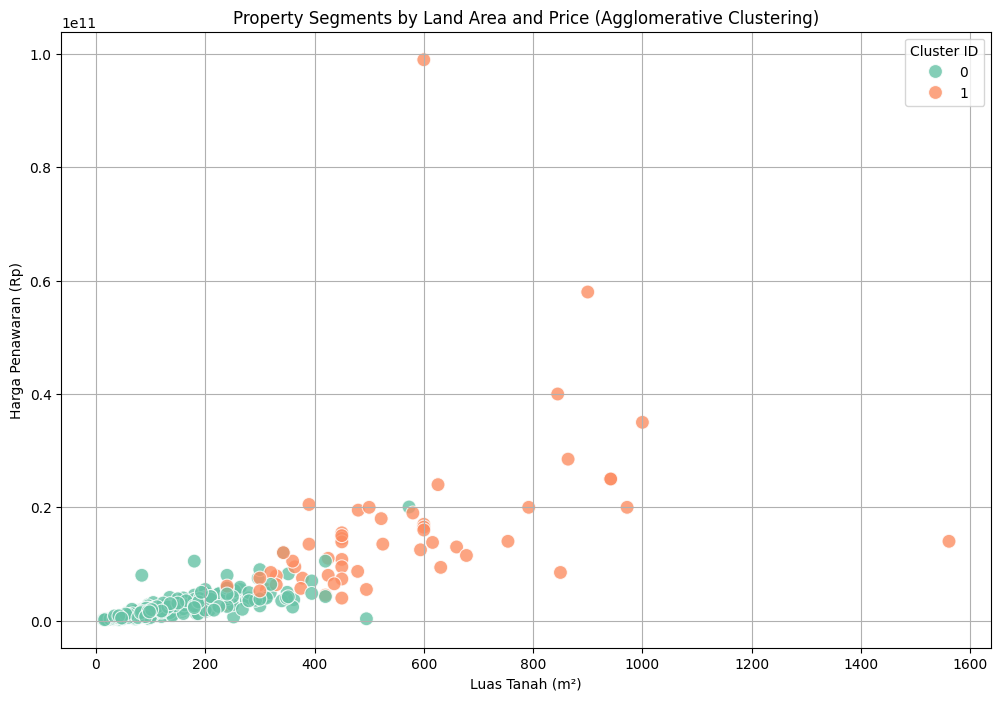

In [288]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.scatterplot(data=new_df,
                x='Luas Tanah',
                y='Harga Penawaran (dari Owner)',
                hue=new_df['Cluster_Ward'].astype(str),  # Cluster sebagai warna
                palette='Set2',
                s=100,
                alpha=0.8)

plt.title('Property Segments by Land Area and Price (Agglomerative Clustering)')
plt.xlabel('Luas Tanah (m²)')
plt.ylabel('Harga Penawaran (Rp)')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()


In [283]:
import plotly.express as px

# Define the columns for the 3D scatter plot
x_col = 'Luas Tanah'
y_col = 'Luas Bangunan'
z_col = 'Harga Penawaran (dari Owner)'

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df,
                    x=x_col,
                    y=y_col,
                    z=z_col,
                    color=new_df['Agglo'].astype(str), # Color points by Agglo cluster, explicitly as string for discrete colors
                    title='Interactive 3D Scatter Plot of Customers by Agglo Clusters')

fig.show()

In [282]:
import plotly.express as px

# Define the columns for the 3D scatter plot
x_col = 'Luas Tanah'
y_col = 'Luas Bangunan'
z_col = 'Harga Penawaran (dari Owner)'

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df,
                    x=x_col,
                    y=y_col,
                    z=z_col,
                    color=new_df['Cluster_Ward'].astype(str), # Color points by Agglo cluster, explicitly as string for discrete colors
                    title='Interactive 3D Scatter Plot of Customers by Ward Clusters')

fig.show()

## Statistical Summary for each cluster

### WARD

In [279]:
cluster_summary_ward = new_df.groupby('Cluster_Ward').agg({
    'Area Category': ['mean'],
    'Nama Daerah': ['mean'],
    'Luas Tanah': ['mean', 'std', 'min', 'max'],
    'Luas Bangunan': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar Mandi': ['mean', 'std', 'min', 'max'],
    'Tingkat/Lantai': ['mean', 'std', 'min', 'max'],
    'Harga Penawaran (dari Owner)': ['mean', 'std', 'min', 'max'],
    'Arah Hadap Rumah': ['mean'],
    'Posisi Rumah': ['mean'],
    'Lebar Jalan Depan Rumah (ROW)': ['mean']
})

# Optional: ubah nama kolom lebih rapi
cluster_summary_ward.columns = ['_'.join(col).strip() for col in cluster_summary_ward.columns.values]
cluster_summary_ward = cluster_summary_ward.reset_index()

# Tampilkan ringkasan
cluster_summary_ward

,Cluster_Ward,Area Category_mean,Nama Daerah_mean,Luas Tanah_mean,Luas Tanah_std,Luas Tanah_min,Luas Tanah_max,Luas Bangunan_mean,Luas Bangunan_std,Luas Bangunan_min,...,Tingkat/Lantai_std,Tingkat/Lantai_min,Tingkat/Lantai_max,Harga Penawaran (dari Owner)_mean,Harga Penawaran (dari Owner)_std,Harga Penawaran (dari Owner)_min,Harga Penawaran (dari Owner)_max,Arah Hadap Rumah_mean,Posisi Rumah_mean,Lebar Jalan Depan Rumah (ROW)_mean
0,0,1.222222,64.365079,155.456349,92.578093,14,573,190.099206,111.231937,14,...,0.484683,1,3,2.635451e+09,2.191827e+09,160000000,20055000000,0.738095,0.099206,1.293651
1,1,2.178571,48.321429,548.678571,243.790827,240,1561,611.339286,222.130369,212,...,0.598700,1,4,1.571913e+10,1.486817e+10,2750000000,99000000000,0.696429,0.107143,1.500000


### BEST PARAMETERS

In [272]:
# Pilih kolom yang ingin dianalisis per cluster
cluster_summary = new_df.groupby(y_hc).agg({
    'Area Category': ['mean'],
    'Nama Daerah': ['mean'],
    'Luas Tanah': ['mean', 'std', 'min', 'max'],
    'Luas Bangunan': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar Mandi': ['mean', 'std', 'min', 'max'],
    'Tingkat/Lantai': ['mean', 'std', 'min', 'max'],
    'Harga Penawaran (dari Owner)': ['mean', 'std', 'min', 'max'],
    'Arah Hadap Rumah': ['mean'],
    'Posisi Rumah': ['mean'],
    'Lebar Jalan Depan Rumah (ROW)': ['mean']
})

# Optional: ubah nama kolom lebih rapi
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index()

# Tampilkan ringkasan
cluster_summary


,index,Area Category_mean,Nama Daerah_mean,Luas Tanah_mean,Luas Tanah_std,Luas Tanah_min,Luas Tanah_max,Luas Bangunan_mean,Luas Bangunan_std,Luas Bangunan_min,...,Tingkat/Lantai_std,Tingkat/Lantai_min,Tingkat/Lantai_max,Harga Penawaran (dari Owner)_mean,Harga Penawaran (dari Owner)_std,Harga Penawaran (dari Owner)_min,Harga Penawaran (dari Owner)_max,Arah Hadap Rumah_mean,Posisi Rumah_mean,Lebar Jalan Depan Rumah (ROW)_mean
0,0,1.397394,61.550489,225.736156,201.019246,14,1561,265.602606,212.655015,14,...,0.506478,1,4,4.708159e+09,6.351742e+09,160000000,58000000000,0.723127,0.100977,1.332248
1,1,1.000000,30.000000,600.000000,NaN,600,600,600.000000,NaN,600,...,NaN,1,1,9.900000e+10,NaN,99000000000,99000000000,3.000000,0.000000,1.000000


## Comparison Between Both Models

A. Distribution of Data Points per Cluster
| Model               | Cluster 0 | Cluster 1 | Total | Catatan                                                                                        |
| ------------------- | --------- | --------- | ----- | ---------------------------------------------------------------------------------------------- |
| **Complete (Best)** | 306       | 2         | 308   | Mayoritas rumah tergabung di Cluster 0, cluster minoritas hanya 2 rumah (sangat besar/mahal)   |
| **Ward**            | 277       | 31        | 308   | Ward lebih sensitif terhadap outlier, cluster minoritas lebih jelas terlihat, tapi masih kecil |

Interpretasi:
- Ward linkage sedikit lebih “agresif” memisahkan rumah yang lebih mahal/luas sebagai cluster sendiri.
- Complete linkage (Best) cenderung lebih stabil, mayoritas rumah tetap dalam satu cluster besar, minoritas hanya 2 rumah ekstrem.

B. Cluster Mean / Median / Mode Values for Features

| Fitur                                    | Cluster 0 (Mayoritas)                     | Cluster 1 (Minoritas)      | Catatan                                                        |
| ---------------------------------------- | ----------------------------------------- | -------------------------- | -------------------------------------------------------------- |
| **Luas Tanah (m²)**                      | ~225                                      | ~600                       | Cluster 1 adalah rumah besar/outlier                           |
| **Luas Bangunan (m²)**                   | ~265                                      | ~611                       | Sama, outlier besar                                            |
| **Harga Penawaran (Rp)**                 | ~4.7 miliar                               | ~99 miliar                 | Cluster minoritas sangat mahal                                 |
| **Area Category (Encoded)**              | ~1.39 (Standard/Premium campuran)         | 1 (Sangat Premium/ekstrem) | Cluster minoritas adalah high-end                              |
| **Jumlah Kamar / Kamar Mandi / Tingkat** | Sedang (rata-rata 4 kamar, 3 kamar mandi) | Ekstrem                    | Cluster minoritas lebih mewah                                  |
| **Posisi Rumah / Arah / Lebar Jalan**    | Standar                                   | Non-standard / Outlier     | Cluster minoritas bisa jadi lokasi strategis atau sangat besar |

Interpretasi:
- Cluster mayoritas mewakili rumah rata-rata → ukuran sedang, harga terjangkau.
- Cluster minoritas mewakili rumah eksklusif → ukuran sangat besar, harga tinggi, fasilitas lebih lengkap.

C.Which Method Gives More Meaningful Segmentation?

- Ward linkage menonjolkan outlier dan memberikan cluster minoritas lebih banyak data → bagus jika tujuan adalah menemukan segmen eksklusif.
- Complete linkage (Best) lebih stabil, cluster minoritas sangat kecil (hanya 2 rumah) → cocok untuk analisis segmentasi mayoritas properti tanpa terlalu dipengaruhi outlier.

Kesimpulan:
- Ward → deteksi outlier lebih efektif, cocok untuk segmentasi premium.
- Complete → segmentasi mayoritas properti lebih stabil, cocok untuk strategi pasar umum.

## Managerial Interpretation & Business Implications

a. Pricing Strategy
- Cluster mayoritas (~225 m², Rp 4–5 miliar) → fokus pada strategi harga kompetitif untuk pasar menengah.
- Cluster minoritas (~600 m², Rp 99 miliar) → bisa premium pricing, target high-end buyers.

b. Area Targeting
- Mayoritas properti → distribusi luas di area standar/premium → strategi promosi masif di area populer.
- Minoritas properti → rumah eksklusif → strategi promosi selektif, mungkin menggunakan agen high-end atau listing eksklusif.

c. Product / Feature Insights
- Cluster mayoritas → rumah 4 kamar, 3 kamar mandi, 2 lantai → bisa dijadikan standar desain properti untuk proyek baru.
- Cluster minoritas → rumah mewah, luas bangunan besar, fasilitas lengkap → bisa dijadikan referensi premium project untuk pasar terbatas.

d. Risk Management
- Dengan mengetahui cluster minoritas high-end, developer atau investor bisa menghindari risiko overpricing atau merancang strategi khusus untuk rumah besar dan mahal.